In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [15]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [16]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\souha\AppData\Local\Temp\ipykernel_21368\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [29]:
from sklearn.model_selection import train_test_split
x=df.iloc[:,1:3]
y = df.iloc[:,0]
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

In [30]:
x_train.shape

(712, 2)

In [31]:
y_train.shape

(712,)

<h1>Viewing if data is normal using kdeplot and QQ Plot</h1>

Text(0.5, 1.0, 'Age QQ Plot')

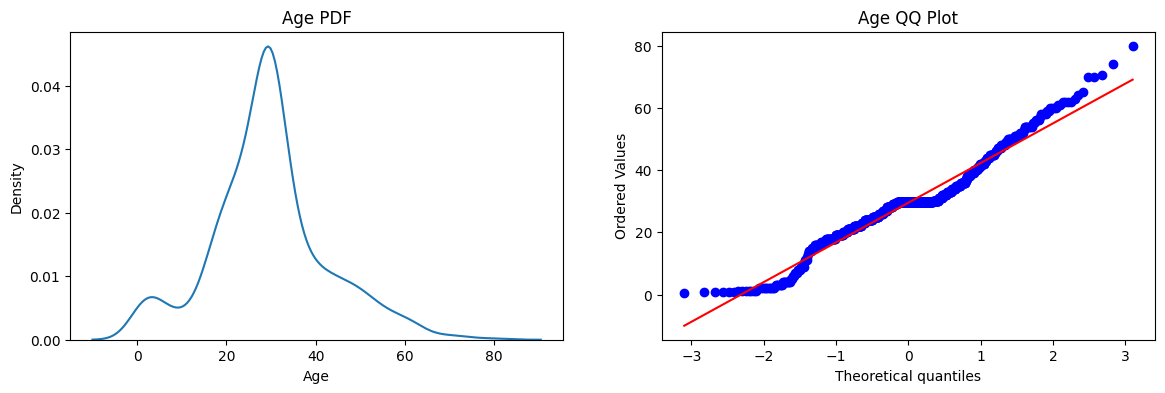

In [19]:
import scipy.stats as stats #for QQ Plot

fig, (ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
sns.kdeplot(x_train['Age'],ax=ax1)
ax1.set_title('Age PDF')

stats.probplot(x_train['Age'],dist='norm',plot=ax2)
ax2.set_title('Age QQ Plot')

Text(0.5, 1.0, 'Fare QQ Plot')

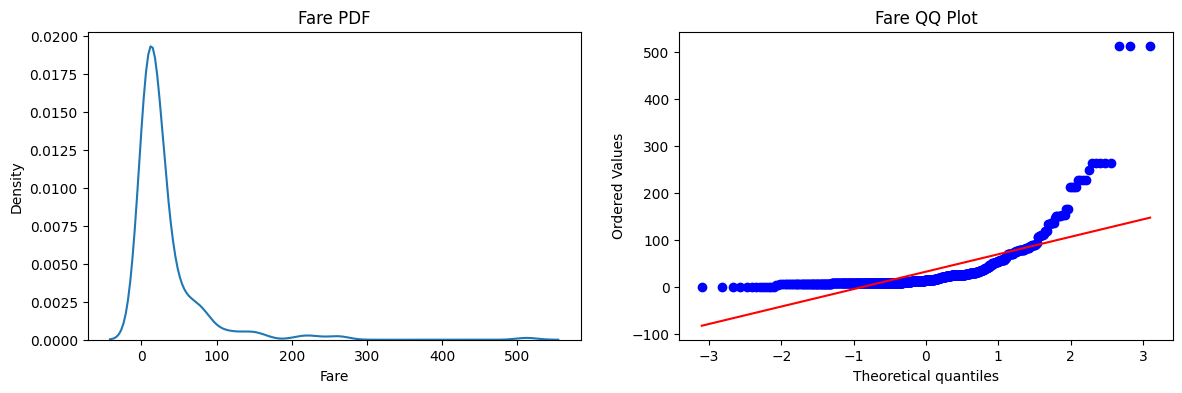

In [20]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))
sns.kdeplot(x_train['Fare'],ax=ax1)
ax1.set_title('Fare PDF')

stats.probplot(x_train['Fare'],dist='norm',plot=ax2)
ax2.set_title('Fare QQ Plot')

<h1>Running Model accuracy before transformation</h1>

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [40]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

y_pred=clf.predict(x_test)
y_pred2=clf2.predict(x_test)

print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred2))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6927374301675978


<h1>Applying Transformation</h1>

In [36]:
from sklearn.preprocessing import FunctionTransformer
trf=FunctionTransformer(func=np.log1p)

In [37]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [38]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

y_pred=clf.predict(x_test_transformed)
y_pred2=clf2.predict(x_test_transformed)

print('Accuracy LR',accuracy_score(y_test,y_pred))
print('Accuracy DT',accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6815642458100558


<h3>We can see a good improvement of accuracy for LR, and we know DT doesnt get affected by these too much so slight improvement.</h3>

<h1>Cross-Validation</h1>

In [48]:
from sklearn.model_selection import cross_val_score
x_transformed=trf.fit_transform(x)

clf=LogisticRegression()
clf2=DecisionTreeClassifier()

print('LR',np.mean(cross_val_score(clf,x_transformed,y,cv=10,scoring='accuracy')))
print('DT',np.mean(cross_val_score(clf2,x_transformed,y,cv=10,scoring='accuracy')))

LR 0.678027465667915
DT 0.6633208489388264


<h1>Visualising Before/After Transformation</h1>

Text(0.5, 1.0, 'Age after Log1')

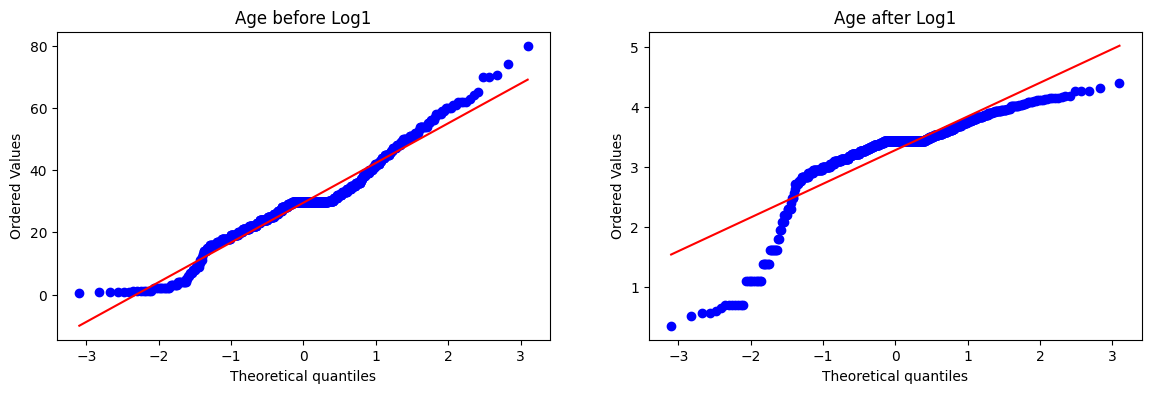

In [49]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

stats.probplot(x_train['Age'],dist='norm',plot=ax1)
ax1.set_title('Age before Log1')

stats.probplot(x_train_transformed['Age'],dist='norm',plot=ax2)
ax2.set_title('Age after Log1')

Text(0.5, 1.0, 'Fare after Log1')

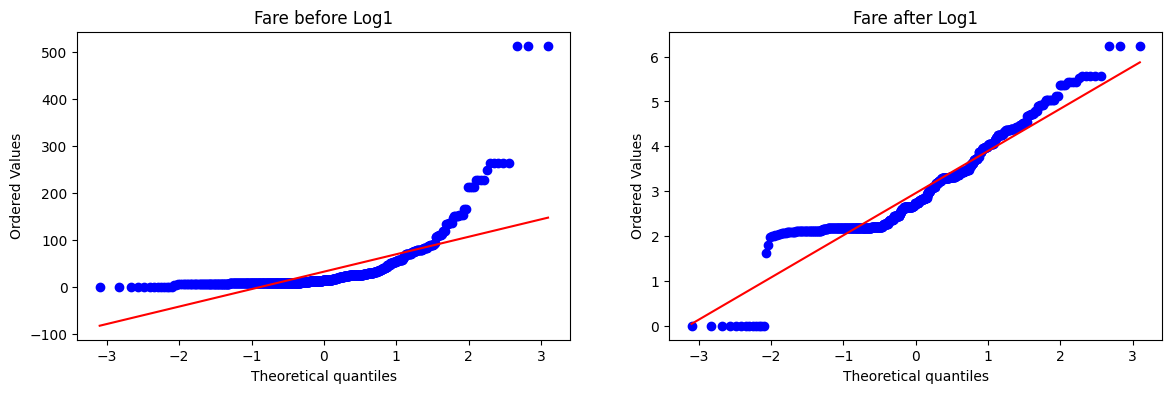

In [50]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

stats.probplot(x_train['Fare'],dist='norm',plot=ax1)
ax1.set_title('Fare before Log1')

stats.probplot(x_train_transformed['Fare'],dist='norm',plot=ax2)
ax2.set_title('Fare after Log1')

<p>Here we see, "Age" doesnt improve much rather becomes worse but "Fare" shows some improvement and is much more normalised than before.</p>

<h1>Creating Transform Function to apply different transformations</h1>

In [51]:
from sklearn.compose import ColumnTransformer

In [64]:
def apply_transform(transform):
    x=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf=ColumnTransformer([('transform',FunctionTransformer(transform),['Fare'])],
                          remainder='passthrough')

    x_trans=trf.fit_transform(x)
    clf=LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,x_trans,y,scoring='accuracy',cv=10)))

    fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(14,4))

    stats.probplot(x['Fare'],dist='norm',plot=ax1)
    ax1.set_title('Fare before transform')
    
    stats.probplot(x_trans[:,0],dist='norm',plot=ax2)
    ax2.set_title('Fare after transform')

Accuracy 0.6431335830212235


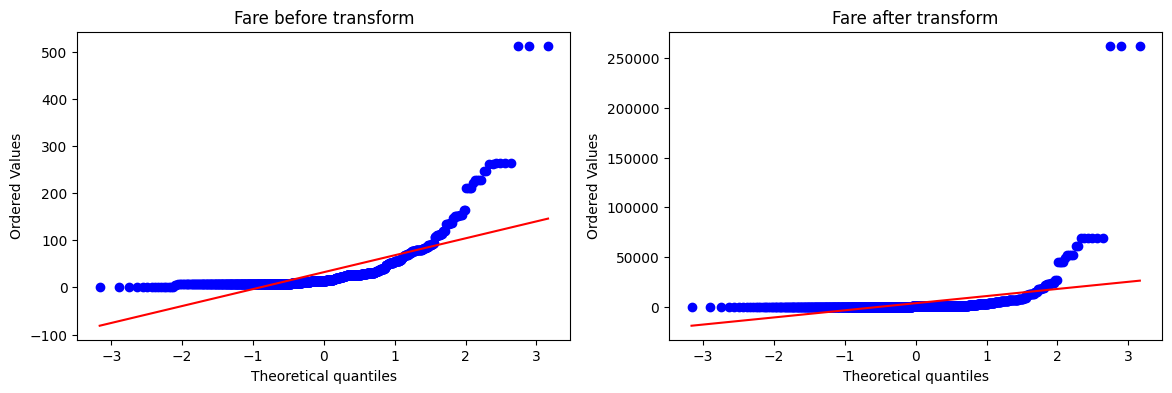

In [70]:
#x**2
apply_transform(lambda x:x**2)

Accuracy 0.61729088639201


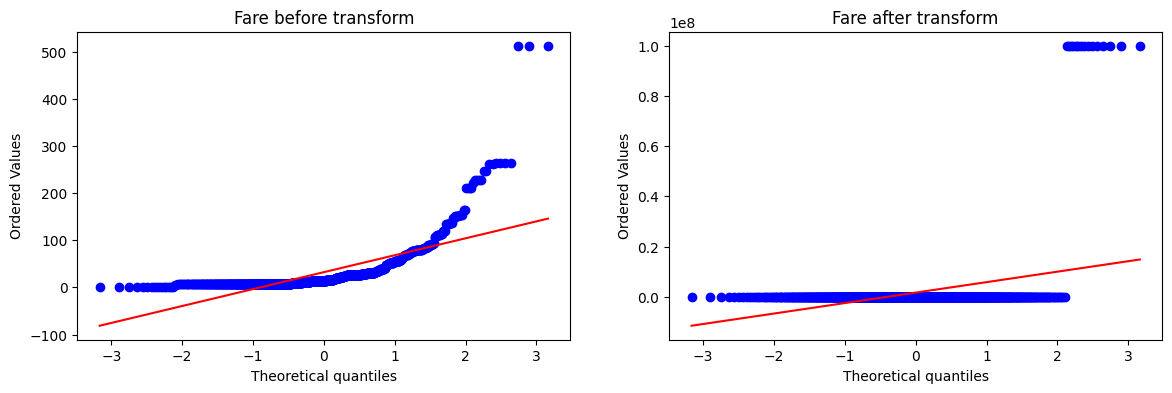

In [71]:
#reciprocal
apply_transform(lambda x:1/(x+0.00000001))
#adding 0.00000001 to avoid denomenator as 0

Accuracy 0.6712609238451936


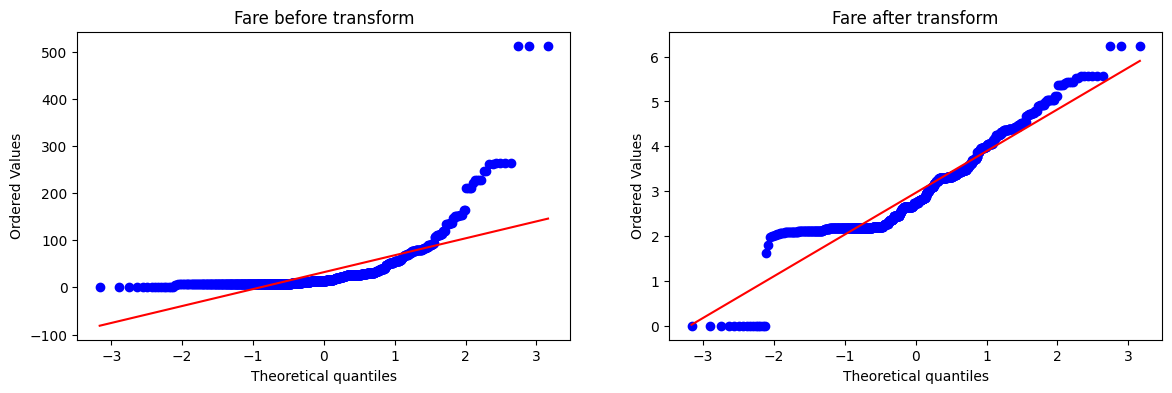

In [74]:
#log1p
apply_transform(np.log1p)